## RIDGE REGRESYONU GRİD SEARCH İLE OPTİMİZASYONU

In [2]:
#Gerekli kütüphanelerin indirilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [3]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [4]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım,Veriyi bölelim:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
ridge=Ridge()
parametreler={"alpha":[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,2,3,4,5,10,20,30,50]}
ridge_gs=GridSearchCV(ridge,parametreler,scoring="r2",cv=5)
ridge_gs.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   2, 3, 4, 5, 10, 20, 30, 50]},
             scoring='r2')

In [6]:
print(ridge_gs.best_params_)
print(ridge_gs.best_estimator_)
print(ridge_gs.best_score_)#ortalmasıdır


{'alpha': 1}
Ridge(alpha=1)
0.707177264934737


In [7]:
#çapraz doğrulama (cross-validation)
all_accuracies=cross_val_score(estimator=ridge_gs.best_estimator_,X=x_train,y=y_train,cv=5)


In [8]:
print(all_accuracies)#  farklı denemedeki score değerleri
print(all_accuracies.mean())#  ortalama başarı
print(all_accuracies.std())#  standart sapma yani ne kadar skorların dalgalandığını söyler.


[0.59028756 0.86202159 0.75828323 0.58997173 0.73532222]
0.707177264934737
0.10467192818729888


In [9]:
#tahmin modelinin katsayıları
#ridgenin ürettiği en iyi modelin tahmin parametreleri:
sabit=ridge_gs.best_estimator_.intercept_  #best_estimator_ en iyi değeri paraametreleridir

print("sabit deger:",sabit)

oznitelik_katsayilari=pd.DataFrame(
                                   ridge_gs.best_estimator_.coef_,x.columns,
                                   columns=['ridge (a=1)öznitelik kaysayilari']
                                    )        
oznitelik_katsayilari

sabit deger: 294.71073010587173


,ridge (a=1)öznitelik kaysayilari
Oda_Sayısı,107.776167
Net_m2,1.478146
Katı,7.135185
Yaşı,-4.234666


In [10]:
ridge_train_score=ridge_gs.best_estimator_.score(x_train,y_train)
ridge_test_score=ridge_gs.best_estimator_.score(x_test,y_test)
print("Eğitim seti için R2:",ridge_train_score)
print("Test seti için R2:",ridge_test_score)


Eğitim seti için R2: 0.7331046122177595
Test seti için R2: 0.6904116932614517


In [11]:
veri["Fiyat_Tahmini"]=ridge_gs.best_estimator_.predict(x)
print(veri[["Fiyat","Fiyat_Tahmini"]].head(20))

    Fiyat  Fiyat_Tahmini
0     475     436.204755
1     475     462.611617
2     450     446.751552
3     450     465.512136
4     475     453.631191
5     475     458.376951
6     475     470.002349
7     475     446.751552
8     450     454.142284
9     475     454.709792
10    475     443.595487
11    525     532.652645
12    550     562.527533
13    575     507.012423
14    550     517.615634
15    575     531.630458
16    500     519.460875
17    550     473.470375
18    525     488.251839
19    500     497.544226


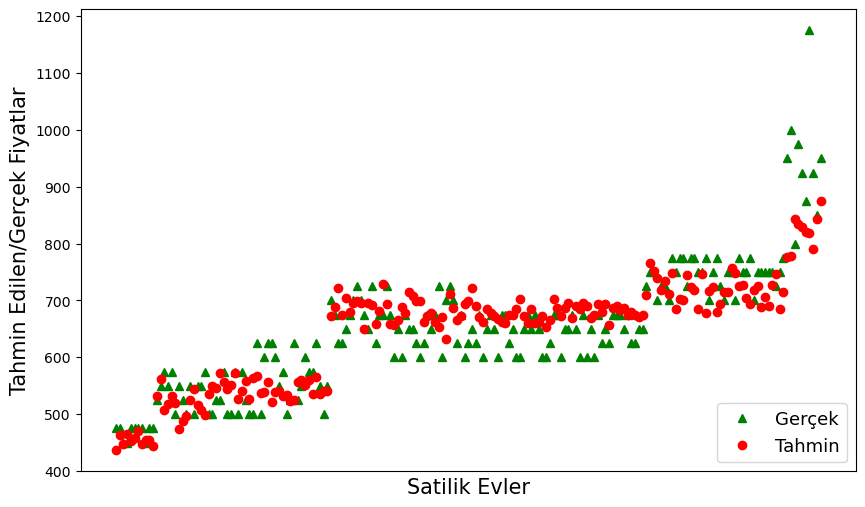

In [12]:
#Grafik: Evlerin gerçek ve tahmin edilmiş fiayatlarını karşılaştırılması:
plt.figure(figsize=(10,6))
plt.xticks(veri["Fiyat"],veri.index.values)
plt.plot(veri["Fiyat"],"g^",label="Gerçek")
plt.xticks(veri["Fiyat_Tahmini"],veri.index.values)
plt.plot(veri["Fiyat_Tahmini"],"ro",label="Tahmin")
plt.xlabel("Satilik Evler",fontsize=15)
plt.ylabel("Tahmin Edilen/Gerçek Fiyatlar",fontsize=15)
plt.legend(fontsize=13,loc="lower right")
plt.show()

In [15]:
Oda_sayisi=3
Net_m2=105
Kati=4
Yaşi=8
print("Yeni evin Fiyatı :",ridge_gs.best_estimator_.predict([[Oda_sayisi,Net_m2,Kati,Yaşi]]))


Yeni evin Fiyatı : [767.90801287]


c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
